In [10]:
import pandas as pd
import numpy as np

file_path = r"C:\Users\Arnav Kasabe\Downloads\Nifty 50 Historical Data (1).csv"
df = pd.read_csv(file_path)

df = df.iloc[::-1].reset_index(drop=True)

df['Date'] = pd.to_datetime(df['Date'], format='%d-%m-%Y')

numeric_cols = ['Price', 'Open', 'High', 'Low']
for col in numeric_cols:
    df[col] = df[col].astype(str).str.replace(',', '').astype(float)

df['Change %'] = df['Change %'].astype(str).str.replace('%', '').astype(float)
df.head()

,Date,Price,Open,High,Low,Vol.,Change %
0,2010-01-04,5232.20,5200.90,5238.45,5167.10,148.65M,0.60
1,2010-01-05,5277.90,5277.15,5288.35,5242.40,240.84M,0.87
2,2010-01-06,5281.80,5278.15,5310.85,5260.05,216.15M,0.07
3,2010-01-07,5263.10,5281.80,5302.55,5244.75,181.25M,-0.35
4,2010-01-08,5244.75,5264.25,5276.75,5234.70,201.91M,-0.35


In [11]:
df_features = df.copy()

df_features['SMA_5'] = df_features['Price'].rolling(window=5).mean()
df_features['SMA_20'] = df_features['Price'].rolling(window=20).mean()

df_features['Momentum_5'] = df_features['Price'].pct_change(periods=5)
df_features['Momentum_10'] = df_features['Price'].pct_change(periods=10)

df_features['Volatility_10'] = df_features['Price'].rolling(window=10).std()

df_features = df_features.dropna().reset_index(drop=True)
state_cols = ['Price', 'SMA_5', 'SMA_20', 'Momentum_5', 'Momentum_10', 'Volatility_10']
for col in state_cols:
    df_features[col] = df_features[col].astype(np.float32)

print(f"Total trading days available for the AI: {len(df_features)}")

print(f"Total trading days available for the AI: {len(df_features)}")
df_features[['Date', 'Price', 'SMA_5', 'SMA_20', 'Momentum_5', 'Volatility_10']].head()

Total trading days available for the AI: 2316
Total trading days available for the AI: 2316


,Date,Price,SMA_5,SMA_20,Momentum_5,Volatility_10
0,2010-02-01,4899.700195,4902.000000,5143.397461,-0.027065,161.891144
1,2010-02-02,4830.100098,4866.439941,5123.292480,-0.035504,149.685944
2,2010-02-03,4931.850098,4882.189941,5105.990234,0.016227,125.567940
3,2010-02-04,4845.350098,4877.810059,5084.167480,-0.004499,90.793419
4,2010-02-05,4718.649902,4845.129883,5056.944824,-0.033470,90.595604


In [17]:
class StockTradingEnv:
    def __init__(self, dataframe, initial_balance=100000):
        self.df = dataframe
        self.initial_balance = initial_balance
        self.state_features = ['Price', 'SMA_5', 'SMA_20', 'Momentum_5', 'Momentum_10', 'Volatility_10']
        self.reset()
        
    def reset(self):
        self.current_step = 0
        self.balance = self.initial_balance
        self.shares_held = 0
        self.net_worth = self.initial_balance
        return self._get_state()
        
    def _get_state(self):
        # EXPLICIT CASTING: Forces NumPy to produce a clean float32 array
        state_vals = self.df.loc[self.current_step, self.state_features].values
        return np.array(state_vals, dtype=np.float32)
        
    def step(self, action):
        current_price = self.df.loc[self.current_step, 'Price']
        
        # 0: Sell, 1: Hold, 2: Buy
        if action == 2:
            if self.balance > 0:
                self.shares_held += self.balance / current_price
                self.balance = 0
        elif action == 0:
            if self.shares_held > 0:
                self.balance += self.shares_held * current_price
                self.shares_held = 0
                
        self.current_step += 1
        done = self.current_step >= len(self.df) - 1
        
        next_price = self.df.loc[self.current_step, 'Price']
        new_net_worth = self.balance + (self.shares_held * next_price)
        
        reward = new_net_worth - self.net_worth
        self.net_worth = new_net_worth
        
        next_state = self._get_state() if not done else None
        
        return next_state, reward, done

In [18]:
# class StockTradingEnv:
#     def __init__(self, dataframe, initial_balance=100000):
#         self.df = dataframe
#         self.initial_balance = initial_balance
        
#         # State indicators we engineered earlier
#         self.state_features = ['Price', 'SMA_5', 'SMA_20', 'Momentum_5', 'Momentum_10', 'Volatility_10']
        
#         self.reset()
        
#     def reset(self):
#         # Reset the simulator back to day 0
#         self.current_step = 0
#         self.balance = self.initial_balance
#         self.shares_held = 0
#         self.net_worth = self.initial_balance
        
#         # Return the very first state data row for the AI to see
#         return self._get_state()
        
#     def _get_state(self):
#         # Extract the state variables for the current day
#         return self.df.loc[self.current_step, self.state_features].values
        
#     def step(self, action):
#         # 1. Capture the current market price before executing the action
#         current_price = self.df.loc[self.current_step, 'Price']
        
#         # 2. Execute Actions (0: Sell, 1: Hold, 2: Buy)
#         if action == 2:  # BUY
#             # Spend all available cash to buy as many shares as possible
#             if self.balance > 0:
#                 self.shares_held += self.balance / current_price
#                 self.balance = 0
                
#         elif action == 0:  # SELL
#             # Liquidate all shares back into cash
#             if self.shares_held > 0:
#                 self.balance += self.shares_held * current_price
#                 self.shares_held = 0
                
#         # Action == 1 is HOLD (do nothing)
        
#         # 3. Advance to the next trading day
#         self.current_step += 1
        
#         # Check if we have run out of historical data rows
#         done = self.current_step >= len(self.df) - 1
        
#         # 4. Calculate new portfolio Net Worth at tomorrow's new price
#         next_price = self.df.loc[self.current_step, 'Price']
#         new_net_worth = self.balance + (self.shares_held * next_price)
        
#         # 5. Define the Reward function: Reward is the absolute daily portfolio value change
#         reward = new_net_worth - self.net_worth
        
#         # Update internal tracking metric
#         self.net_worth = new_net_worth
        
#         # Get the new state data row for tomorrow
#         next_state = self._get_state() if not done else None
        
#         return next_state, reward, done

In [13]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
from collections import deque
import random
import matplotlib.pyplot as plt

# Check GPU availability
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Define Q-Network
class QNetwork(nn.Module):
    def __init__(self, state_dim, action_dim):
        super(QNetwork, self).__init__()
        self.fc = nn.Sequential(
            nn.Linear(state_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 64),
            nn.ReLU(),
            nn.Linear(64, action_dim)
        )

    def forward(self, x):
        return self.fc(x)

In [21]:
class ReplayBuffer:
    def __init__(self, capacity=10000):
        self.buffer = deque(maxlen=capacity)

    def push(self, state, action, reward, next_state, done):
        self.buffer.append((state, action, reward, next_state, done))

    def sample(self, batch_size):
        state, action, reward, next_state, done = zip(*random.sample(self.buffer, batch_size))
        return (
            np.array(state, dtype=np.float32),
            np.array(action, dtype=np.int64),
            np.array(reward, dtype=np.float32),
            np.array(next_state, dtype=np.float32),
            np.array(done, dtype=np.float32)
        )

    def __len__(self):
        return len(self.buffer)

class DQNAgent:
    def __init__(self, state_dim, action_dim, lr=1e-3, gamma=0.99, epsilon=1.0, epsilon_decay=0.995, epsilon_min=0.01):
        self.state_dim = state_dim
        self.action_dim = action_dim
        self.gamma = gamma
        self.epsilon = epsilon
        self.epsilon_decay = epsilon_decay
        self.epsilon_min = epsilon_min

        # Main & Target Networks
        self.policy_net = QNetwork(state_dim, action_dim).to(device)
        self.target_net = QNetwork(state_dim, action_dim).to(device)
        self.target_net.load_state_dict(self.policy_net.state_dict())
        self.target_net.eval()

        self.optimizer = optim.Adam(self.policy_net.parameters(), lr=lr)
        self.memory = ReplayBuffer()

    def select_action(self, state):
        if random.random() < self.epsilon:
            return random.randint(0, self.action_dim - 1)
        
        state_t = torch.FloatTensor(state).unsqueeze(0).to(device)
        with torch.no_grad():
            q_values = self.policy_net(state_t)
        return torch.argmax(q_values, dim=1).item()

    def train_step(self, batch_size=64):
        if len(self.memory) < batch_size:
            return

        states, actions, rewards, next_states, dones = self.memory.sample(batch_size)

        states_t = torch.FloatTensor(states).to(device)
        actions_t = torch.LongTensor(actions).unsqueeze(1).to(device)
        rewards_t = torch.FloatTensor(rewards).unsqueeze(1).to(device)
        next_states_t = torch.FloatTensor(next_states).to(device)
        dones_t = torch.FloatTensor(dones).unsqueeze(1).to(device)

        # Current Q Value
        q_values = self.policy_net(states_t).gather(1, actions_t)

        # Target Q Value calculation using Target Network
        with torch.no_grad():
            max_next_q = self.target_net(next_states_t).max(1, keepdim=True)[0]
            target_q = rewards_t + (1 - dones_t) * self.gamma * max_next_q

        # MSE Loss
        loss = nn.MSELoss()(q_values, target_q)

        self.optimizer.zero_grad()
        loss.backward()
        self.optimizer.step()

    def update_epsilon(self):
        self.epsilon = max(self.epsilon_min, self.epsilon * self.epsilon_decay)

    def update_target_network(self):
        self.target_net.load_state_dict(self.policy_net.state_dict())

In [22]:
# Environment and Hyperparameters initialization
env = StockTradingEnv(df_features, initial_balance=100000)
state_dim = len(env.state_features)
action_dim = 3  # 0: Sell, 1: Hold, 2: Buy

agent = DQNAgent(state_dim=state_dim, action_dim=action_dim)

episodes = 50
batch_size = 64
target_update_freq = 5

net_worth_history = []

print("🤖 Starting DQN Model Training...")

for episode in range(1, episodes + 1):
    state = env.reset()
    done = False
    
    while not done:
        action = agent.select_action(state)
        next_state, reward, done = env.step(action)
        
        # Avoid storing None states when episode ends
        if done:
            next_state = state
            
        agent.memory.push(state, action, reward, next_state, done)
        agent.train_step(batch_size)
        
        state = next_state

    agent.update_epsilon()
    
    # Update Target Network periodically
    if episode % target_update_freq == 0:
        agent.update_target_network()
        
    net_worth_history.append(env.net_worth)
    print(f"Episode {episode:02d}/{episodes} | Ending Portfolio Value: ₹{env.net_worth:,.2f} | Epsilon: {agent.epsilon:.4f}")

print("\n✅ Training Complete!")

🤖 Starting DQN Model Training...
Episode 01/50 | Ending Portfolio Value: ₹118,843.56 | Epsilon: 0.9950
Episode 02/50 | Ending Portfolio Value: ₹139,966.97 | Epsilon: 0.9900
Episode 03/50 | Ending Portfolio Value: ₹99,482.16 | Epsilon: 0.9851
Episode 04/50 | Ending Portfolio Value: ₹106,394.52 | Epsilon: 0.9801
Episode 05/50 | Ending Portfolio Value: ₹144,491.53 | Epsilon: 0.9752
Episode 06/50 | Ending Portfolio Value: ₹168,881.22 | Epsilon: 0.9704
Episode 07/50 | Ending Portfolio Value: ₹223,782.56 | Epsilon: 0.9655
Episode 08/50 | Ending Portfolio Value: ₹180,905.59 | Epsilon: 0.9607
Episode 09/50 | Ending Portfolio Value: ₹162,759.69 | Epsilon: 0.9559
Episode 10/50 | Ending Portfolio Value: ₹260,197.72 | Epsilon: 0.9511
Episode 11/50 | Ending Portfolio Value: ₹188,553.78 | Epsilon: 0.9464
Episode 12/50 | Ending Portfolio Value: ₹110,086.68 | Epsilon: 0.9416
Episode 13/50 | Ending Portfolio Value: ₹159,743.89 | Epsilon: 0.9369
Episode 14/50 | Ending Portfolio Value: ₹112,855.45 | Epsi

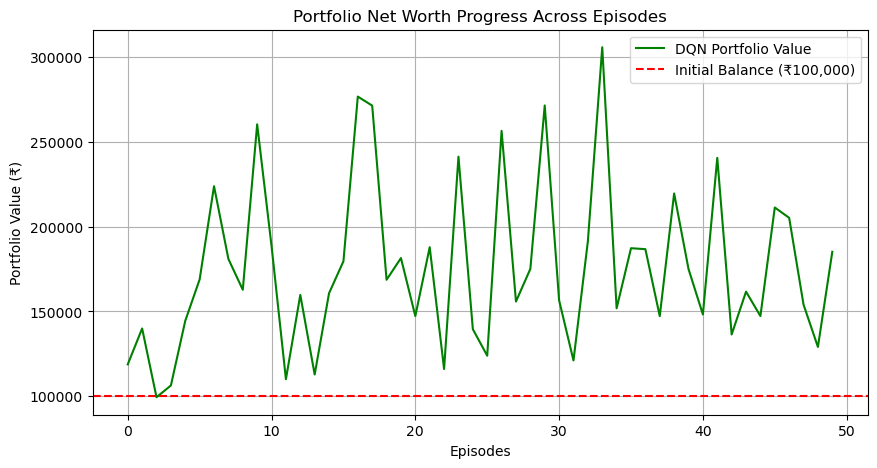

In [23]:
plt.figure(figsize=(10, 5))
plt.plot(net_worth_history, label="DQN Portfolio Value", color="green")
plt.axhline(y=100000, color="r", linestyle="--", label="Initial Balance (₹100,000)")
plt.title("Portfolio Net Worth Progress Across Episodes")
plt.xlabel("Episodes")
plt.ylabel("Portfolio Value (₹)")
plt.legend()
plt.grid(True)
plt.show()

In [6]:
import random

# Initialise our freshly coded environment using our data matrix
env = StockTradingEnv(df_features, initial_balance=100000)
state = env.reset()
done = False

print(f"🚀 Starting Test Run. Initial Portfolio Net Worth: ₹{env.net_worth:,.2f}")

while not done:
    # Randomly select Action 0, 1, or 2
    random_action = random.choice([0, 1, 2])
    
    # Execute step inside environment
    state, reward, done = env.step(random_action)

print(f"🏁 Simulation Finished!")
print(f"Ending Portfolio Net Worth: ₹{env.net_worth:,.2f}")

🚀 Starting Test Run. Initial Portfolio Net Worth: ₹100,000.00
🏁 Simulation Finished!
Ending Portfolio Net Worth: ₹171,509.14


In [20]:
print(df_features[['Price', 'SMA_5', 'SMA_20', 'Momentum_5', 'Momentum_10', 'Volatility_10']].dtypes)

Price            float32
SMA_5            float32
SMA_20           float32
Momentum_5       float32
Momentum_10      float32
Volatility_10    float32
dtype: object
